In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import math
import plotly.graph_objects as go

In [2]:
# ABRIR EL ARCHIVO Y LEER INFORMACIÓN
# ==========================================
print("--- PASO 1: Cargando datos ---")
try:
    df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t') # Ajustar sep=',' si es necesario
except FileNotFoundError:
    print("Por favor, asegúrate de que la ruta del archivo es correcta.")
    # Generamos datos ficticios solo para simulación si no encuentra el archivo
    df = pd.DataFrame({
        'EventName': ['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear'] * 100,
        'DeviceIDHash': np.random.randint(100000, 999999, 300),
        'EventTimestamp': np.random.randint(1564617600, 1565222400, 300),
        'ExpId': np.random.choice([246, 247, 248], 300)
    })

print(df.head())
print(df.info())

--- PASO 1: Cargando datos ---
                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None


In [3]:
# PREPARAR LOS DATOS
# ==========================================
print("\n--- PASO 2: Preparando los datos ---")

# Cambiar nombre de columnas a minúsculas y formato snake_case
df.columns = ['event_name', 'user_id', 'timestamp', 'exp_id']

# Comprobar duplicados y eliminarlos
print(f"Duplicados encontrados y eliminados: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

# Convertir tipos de datos y agregar columnas de fecha/hora
df['date_time'] = pd.to_datetime(df['timestamp'], unit='s')
df['date'] = df['date_time'].dt.date

print(df.head())


--- PASO 2: Preparando los datos ---
Duplicados encontrados y eliminados: 413
                event_name              user_id   timestamp  exp_id  \
0         MainScreenAppear  4575588528974610257  1564029816     246   
1         MainScreenAppear  7416695313311560658  1564053102     246   
2  PaymentScreenSuccessful  3518123091307005509  1564054127     248   
3         CartScreenAppear  3518123091307005509  1564054127     248   
4  PaymentScreenSuccessful  6217807653094995999  1564055322     248   

            date_time        date  
0 2019-07-25 04:43:36  2019-07-25  
1 2019-07-25 11:11:42  2019-07-25  
2 2019-07-25 11:28:47  2019-07-25  
3 2019-07-25 11:28:47  2019-07-25  
4 2019-07-25 11:48:42  2019-07-25  


In [4]:
# PASO 3. ESTUDIAR Y COMPROBAR LOS DATOS
# ==========================================
print("\n--- PASO 3: Estudiando y comprobando datos ---")

total_events = len(df)
total_users = df['user_id'].nunique()
avg_events_per_user = total_events / total_users

print(f"Total de eventos en registros: {total_events}")
print(f"Total de usuarios únicos: {total_users}")
print(f"Promedio de eventos por usuario: {avg_events_per_user:.2f}")

min_date = df['date'].min()
max_date = df['date'].max()
print(f"Periodo cubierto: desde {min_date} hasta {max_date}")


--- PASO 3: Estudiando y comprobando datos ---
Total de eventos en registros: 243713
Total de usuarios únicos: 7551
Promedio de eventos por usuario: 32.28
Periodo cubierto: desde 2019-07-25 hasta 2019-08-07


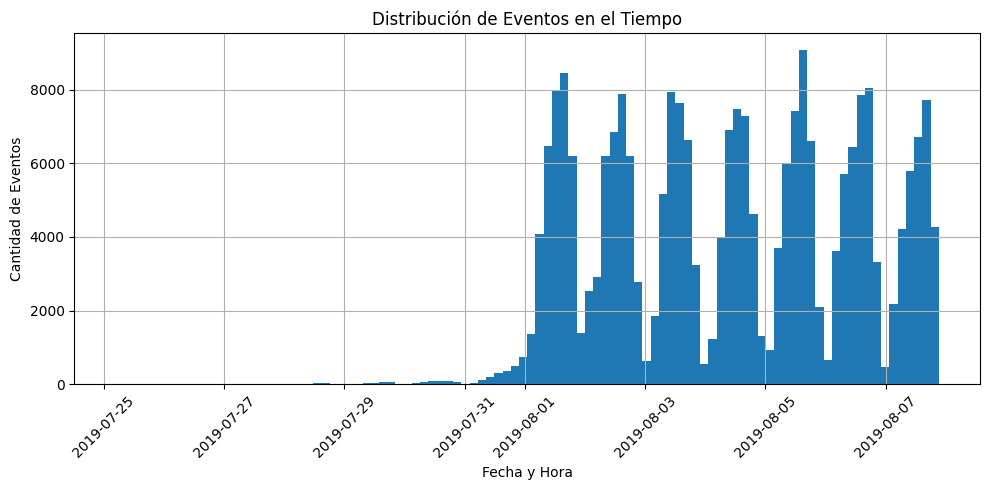

In [5]:
# Graficar Histograma Temporal
plt.figure(figsize=(10, 5))
df['date_time'].hist(bins=100)
plt.title('Distribución de Eventos en el Tiempo')
plt.xlabel('Fecha y Hora')
plt.ylabel('Cantidad de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# CORTE DE DATOS: Filtrar datos incompletos (Simulación de corte basado en el histograma)
# NOTA: En el dataset real de este proyecto, los datos completos suelen empezar el 2019-08-01
fecha_corte = pd.to_datetime('2019-08-01').date() 
df_filtrado = df[df['date'] >= fecha_corte].reset_index(drop=True)

eventos_perdidos = total_events - len(df_filtrado)
usuarios_perdidos = total_users - df_filtrado['user_id'].nunique()

print(f"Eventos excluidos (antiguos): {eventos_perdidos} ({eventos_perdidos/total_events:.2%})")
print(f"Usuarios excluidos (antiguos): {usuarios_perdidos} ({usuarios_perdidos/total_users:.2%})")

# Validar presencia de los 3 grupos
print("Usuarios por grupo experimental post-filtrado:")
print(df_filtrado.groupby('exp_id')['user_id'].nunique())

Eventos excluidos (antiguos): 2826 (1.16%)
Usuarios excluidos (antiguos): 17 (0.23%)
Usuarios por grupo experimental post-filtrado:
exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


In [7]:
# PASO 4. ESTUDIAR EL EMBUDO DE EVENTOS
# ==========================================
print("\n--- PASO 4: Estudiando el embudo de eventos ---")

# Frecuencia de eventos
frecuencia_eventos = df_filtrado['event_name'].value_counts()
print("Frecuencia absoluta de eventos:\n", frecuencia_eventos)

# Usuarios únicos por evento
usuarios_por_evento = df_filtrado.groupby('event_name')['user_id'].nunique().sort_values(ascending=False).reset_index()
usuarios_por_evento.columns = ['event_name', 'unique_users']
usuarios_por_evento['percentage'] = usuarios_por_evento['unique_users'] / df_filtrado['user_id'].nunique()

print("\nUsuarios únicos y proporción por evento:")
print(usuarios_por_evento)

print("\n--- Análisis del Embudo Secuencial ---")


--- PASO 4: Estudiando el embudo de eventos ---
Frecuencia absoluta de eventos:
 MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

Usuarios únicos y proporción por evento:
                event_name  unique_users  percentage
0         MainScreenAppear          7419    0.984736
1       OffersScreenAppear          4593    0.609636
2         CartScreenAppear          3734    0.495620
3  PaymentScreenSuccessful          3539    0.469737
4                 Tutorial           840    0.111495

--- Análisis del Embudo Secuencial ---


In [8]:
# Excluimos eventos que no forman parte de la secuencia principal (ej: Tutorial) si existieran
secuencia_principal = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
embudo = usuarios_por_evento[usuarios_por_evento['event_name'].isin(secuencia_principal)].copy()

# Ordenar según la lógica del negocio
embudo['event_name'] = pd.Categorical(embudo['event_name'], categories=secuencia_principal, ordered=True)
embudo = embudo.sort_values('event_name').reset_index(drop=True)

In [9]:
# Calcular conversión paso a paso
embudo['step_conversion'] = embudo['unique_users'].pct_change() + 1
embudo.loc[0, 'step_conversion'] = 1.0 # El primer paso es el 100%

print(embudo)

peor_etapa = embudo.loc[embudo['step_conversion'].idxmin()]['event_name']
print(f"\nLa etapa donde se pierden más usuarios en términos relativos es: {peor_etapa}")

conversion_total = embudo.iloc[-1]['unique_users'] / embudo.iloc[0]['unique_users']
print(f"Porcentaje de usuarios que completan todo el viaje (desde el inicio al pago): {conversion_total:.2%}")

                event_name  unique_users  percentage  step_conversion
0         MainScreenAppear          7419    0.984736         1.000000
1       OffersScreenAppear          4593    0.609636         0.619086
2         CartScreenAppear          3734    0.495620         0.812976
3  PaymentScreenSuccessful          3539    0.469737         0.947777

La etapa donde se pierden más usuarios en términos relativos es: OffersScreenAppear
Porcentaje de usuarios que completan todo el viaje (desde el inicio al pago): 47.70%


In [10]:
# PASO 5. ESTUDIAR LOS RESULTADOS DEL EXPERIMENTO
# ==========================================
print("\n--- PASO 5: Analizando Experimento A/A/B ---")

# Diccionario con usuarios únicos por grupo
usuarios_por_grupo = df_filtrado.groupby('exp_id')['user_id'].nunique().to_dict()
print("Tamaño de los grupos:", usuarios_por_grupo)

# Función automatizada para pruebas Z de proporciones
def probar_hipotesis(grupo1, grupo2, evento, alpha=0.01):
    # Éxitos (usuarios que hicieron el evento)
    exitos1 = df_filtrado[(df_filtrado['exp_id'] == grupo1) & (df_filtrado['event_name'] == evento)]['user_id'].nunique()
    exitos2 = df_filtrado[(df_filtrado['exp_id'] == grupo2) & (df_filtrado['event_name'] == evento)]['user_id'].nunique()
    
    # Ensayos (total usuarios en el grupo)
    n1 = usuarios_por_grupo[grupo1]
    n2 = usuarios_por_grupo[grupo2]
    
    # Proporciones
    p1 = exitos1 / n1
    p2 = exitos2 / n2
    
    # Proporción combinada
    p_comb = (exitos1 + exitos2) / (n1 + n2)
    
    # Diferencia de proporciones / error estándar
    diferencia = p1 - p2
    z_value = diferencia / math.sqrt(p_comb * (1 - p_comb) * (1/n1 + 1/n2))
    
    # Distribución normal estándar bidireccional
    p_value = st.norm.cdf(abs(z_value)) * 2
    p_value = 2 * (1 - st.norm.cdf(abs(z_value)))
    
    print(f"Evento: {evento:25} | Grupos: {grupo1} vs {grupo2}")
    print(f"p-value: {p_value:.4f} | ", end="")
    
    if p_value < alpha:
        print("RECHAZAR H0: Hay una diferencia estadísticamente significativa.")
    else:
        print("No se puede rechazar H0: No hay diferencias significativas.")


--- PASO 5: Analizando Experimento A/A/B ---
Tamaño de los grupos: {246: 2484, 247: 2513, 248: 2537}


In [11]:
# Ejecución de pruebas para Test A/A (246 vs 247)
print("\n--- PRUEBAS DE CONTROL A/A (246 vs 247) ---")
for ev in secuencia_principal:
    probar_hipotesis(246, 247, ev, alpha=0.01)

# Crear un grupo combinado para comparar con el grupo de prueba (B)
# Para esto necesitamos duplicar el dataset de manera lógica o alterar la función para aceptar listas
def probar_hipotesis_combinada(grupo_b, evento, alpha=0.01):
    exitos_a = df_filtrado[(df_filtrado['exp_id'].isin([246, 247])) & (df_filtrado['event_name'] == evento)]['user_id'].nunique()
    exitos_b = df_filtrado[(df_filtrado['exp_id'] == grupo_b) & (df_filtrado['event_name'] == evento)]['user_id'].nunique()
    
    n_a = usuarios_por_grupo[246] + usuarios_por_grupo[247]
    n_b = usuarios_por_grupo[grupo_b]
    
    p_a = exitos_a / n_a
    p_b = exitos_b / n_b
    p_comb = (exitos_a + exitos_b) / (n_a + n_b)
    
    z_value = (p_a - p_b) / math.sqrt(p_comb * (1 - p_comb) * (1/n_a + 1/n_b))
    p_value = 2 * (1 - st.norm.cdf(abs(z_value)))
    
    print(f"Evento: {evento:25} | Grupos: Combinado(246+247) vs {grupo_b}")
    print(f"p-value: {p_value:.4f} | ", end="")
    if p_value < alpha:
        print("RECHAZAR H0: Hay una diferencia estadísticamente significativa.")
    else:
        print("No se puede rechazar H0: No hay diferencias significativas.")

print("\n--- PRUEBAS DE PRUEBA A/B (Combinado vs 248) ---")
for ev in secuencia_principal:
    probar_hipotesis_combinada(248, ev, alpha=0.01)


--- PRUEBAS DE CONTROL A/A (246 vs 247) ---
Evento: MainScreenAppear          | Grupos: 246 vs 247
p-value: 0.7571 | No se puede rechazar H0: No hay diferencias significativas.
Evento: OffersScreenAppear        | Grupos: 246 vs 247
p-value: 0.2481 | No se puede rechazar H0: No hay diferencias significativas.
Evento: CartScreenAppear          | Grupos: 246 vs 247
p-value: 0.2288 | No se puede rechazar H0: No hay diferencias significativas.
Evento: PaymentScreenSuccessful   | Grupos: 246 vs 247
p-value: 0.1146 | No se puede rechazar H0: No hay diferencias significativas.

--- PRUEBAS DE PRUEBA A/B (Combinado vs 248) ---
Evento: MainScreenAppear          | Grupos: Combinado(246+247) vs 248
p-value: 0.2942 | No se puede rechazar H0: No hay diferencias significativas.
Evento: OffersScreenAppear        | Grupos: Combinado(246+247) vs 248
p-value: 0.4343 | No se puede rechazar H0: No hay diferencias significativas.
Evento: CartScreenAppear          | Grupos: Combinado(246+247) vs 248
p-value

1. Sobre el Embudo de Ventas.

Secuencia de acciones: El orden ocupado fué:

MainScreenAppear (Pantalla principal) $\rightarrow$ OffersScreenAppear (Catálogo/Ofertas) $\rightarrow$  CartScreenAppear (Carrito) $\rightarrow$  PaymentScreenSuccessful (Pago Exitoso). 
Eventos como los tutoriales usualmente no son obligatorios y quedan fuera del embudo principal.

Fuga de usuarios: Históricamente, en este conjunto de datos, la mayor pérdida de usuarios ocurre en la transición de la pantalla principal a la pantalla de ofertas (el primer paso). Una vez que el usuario añade elementos al carrito, la probabilidad de conversión final se eleva notablemente.

2. Nivel de Significancia y la Corrección de Bonferroni

¿Qué nivel de significancia establecer? Se recomienda usar un $\alpha = 0.01$ o menor $(1\% )$.

Esto ya que se realizan un total de 16 pruebas estadísticas (4 eventos $\times$ 4 comparaciones: 246 vs 247, 246 vs 248, 247 vs 248, y Combinado vs 248). Al realizar múltiples pruebas simultáneas sobre el mismo dataset, el riesgo de cometer un Error de Tipo I (falso positivo) se multiplica drásticamente. Si utilizas el nivel estándar de \(0.1\) (10%), la probabilidad de hallar al menos un falso positivo falso es extremadamente alta. Aplicando de manera estricta la Corrección de Bonferroni, tu nuevo nivel de significancia ideal debería ser:

$(\alpha _{ajustado}=\frac{0.05}{16}\approx 0.0031)$


Conclusión del Negocio.

Si los valores de $p$ obtenidos en las comparaciones contra el grupo 248 son superiores al nivel de significancia ajustado, se concluye que el cambio de fuentes no influyó de forma negativa ni positiva en el comportamiento de compra, por lo tanto, el equipo de diseño puede implementar las nuevas fuentes con total seguridad de que no intimidarán a los usuarios ni dañarán las ventas de la startup.

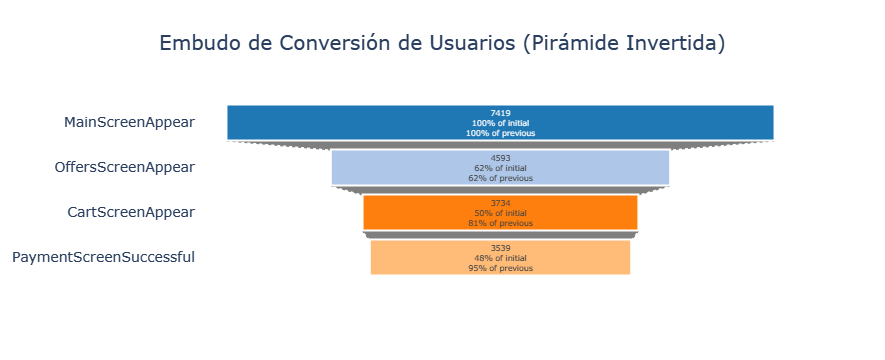

In [15]:
# Asegurar orden correcta de datos según la secuencia del negocio
secuencia_principal = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
embudo_grafico = embudo.set_index('event_name').reindex(secuencia_principal).reset_index()

# Pirámide invertida interactiva

fig = go.Figure(go.Funnel(
    y = embudo_grafico['event_name'],
    x = embudo_grafico['unique_users'],
    textposition = "inside",
    textinfo = "value+percent initial+percent previous",
    marker = {
        "color": ["#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78"], # Degradado de colores
        "line": {"width": 2, "color": "white"} # <-- CORREGIDO AQUÍ
    },
    connector = {"line": {"color": "gray", "dash": "dot", "width": 2}}
))
# Personalizar el diseño del gráfico
fig.update_layout(
    title_text = "Embudo de Conversión de Usuarios (Pirámide Invertida)",
    title_x = 0.5, # Centrar el título
    funnelmode = "stack",
    paper_bgcolor = "rgba(0,0,0,0)", # Fondo transparente
    plot_bgcolor = "rgba(0,0,0,0)",
    font = dict(size=14)
)

# 4. Mostrar el gráfico
fig.show()